<a href="https://colab.research.google.com/github/Sohan-tough/EthicsAI_Experiments/blob/main/Exp9_EthicsAI_23102A0056.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install codecarbon

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.8/380.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 51.2 MB/s eta 0:00:00
  Attempting uninstall: psutil
    Found existing installation: psutil 5.9.5
    Uninstalling psutil-5.9.5:
      Successfully uninstalled psutil-5.9.5


In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_breast_cancer

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from codecarbon import EmissionsTracker

import matplotlib.pyplot as plt

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [3]:
results = []

🌳 1. Decision Tree

In [4]:
tracker = EmissionsTracker()
tracker.start()

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

emissions = tracker.stop()

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

results.append(("Decision Tree", acc, emissions))

[codecarbon WARNING @ 14:26:44] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 14:26:44] [setup] RAM Tracking...
[codecarbon INFO @ 14:26:44] [setup] CPU Tracking...
[codecarbon WARNING @ 14:26:45] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 14:26:45] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 14:26:45] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 14:26:45] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 14:26:45] [setup] GPU Tracking...
[codecarbon INFO @ 14:26:45] No GPU found.
[codecarbon INFO @ 14:26:45] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation mo

📈 2. Logistic Regression

In [5]:
tracker = EmissionsTracker()
tracker.start()

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

emissions = tracker.stop()

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

results.append(("Logistic Regression", acc, emissions))

[codecarbon WARNING @ 14:27:01] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 14:27:01] [setup] RAM Tracking...
[codecarbon INFO @ 14:27:01] [setup] CPU Tracking...
[codecarbon WARNING @ 14:27:01] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 14:27:01] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 14:27:01] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 14:27:01] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 14:27:01] [setup] GPU Tracking...
[codecarbon INFO @ 14:27:01] No GPU found.
[codecarbon INFO @ 14:27:01] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation mo

📊 3. Naive Bayes

In [6]:
tracker = EmissionsTracker()
tracker.start()

model = GaussianNB()
model.fit(X_train, y_train)

emissions = tracker.stop()

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

results.append(("Naive Bayes", acc, emissions))

[codecarbon WARNING @ 14:28:23] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 14:28:23] [setup] RAM Tracking...
[codecarbon INFO @ 14:28:23] [setup] CPU Tracking...
[codecarbon WARNING @ 14:28:23] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 14:28:23] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 14:28:23] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 14:28:23] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 14:28:23] [setup] GPU Tracking...
[codecarbon INFO @ 14:28:23] No GPU found.
[codecarbon INFO @ 14:28:23] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation mo

Graph (Accuracy vs Carbon Emission

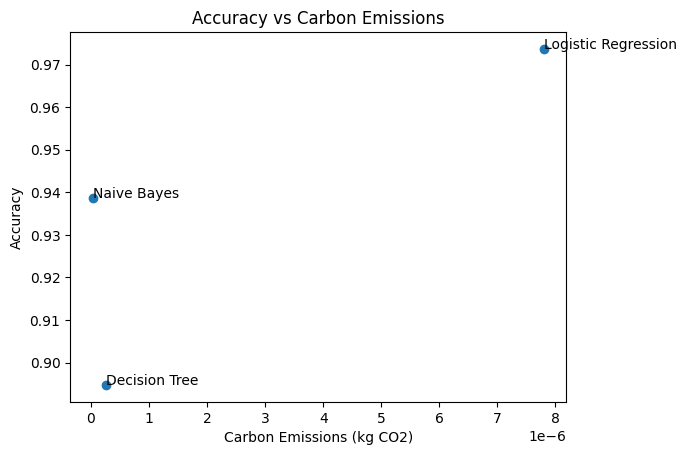

In [7]:
models = [r[0] for r in results]
accuracy = [r[1] for r in results]
emissions = [r[2] for r in results]

plt.scatter(emissions, accuracy)

for i, model in enumerate(models):
    plt.text(emissions[i], accuracy[i], model)

plt.xlabel("Carbon Emissions (kg CO2)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Carbon Emissions")

plt.show()

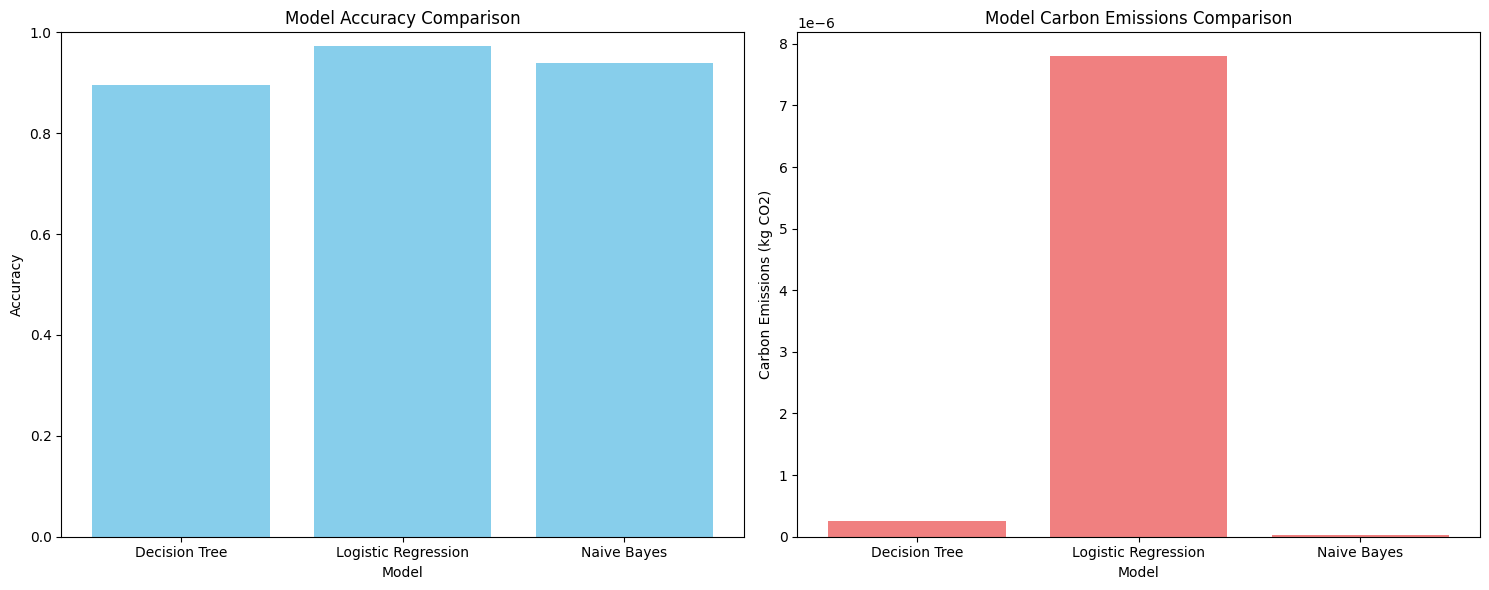

In [8]:
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart for Accuracy
ax1.bar(models, accuracy, color='skyblue')
ax1.set_xlabel('Model')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Comparison')
ax1.set_ylim(0, 1) # Accuracy is between 0 and 1

# Bar chart for Carbon Emissions
ax2.bar(models, emissions, color='lightcoral')
ax2.set_xlabel('Model')
ax2.set_ylabel('Carbon Emissions (kg CO2)')
ax2.set_title('Model Carbon Emissions Comparison')

plt.tight_layout()
plt.show()